In [1]:
import pandas as pd
import numpy as np
from Preprocessing import CombinedPreprocessor
from RandomCV import RandomCV
from GroupKFoldCV import GroupKFoldCV
from SpatialPlusCV import SpatialPlusCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor

from IPython.display import display

In [3]:
p = CombinedPreprocessor()

indices_6182020 = pd.read_csv("../Datasets/Indices_Combined/2020/June_18_2020_New.csv")
indices_6232020 = pd.read_csv("../Datasets/Indices_Combined/2020/June_23_2020_New.csv")
indices_6302020 = pd.read_csv("../Datasets/Indices_Combined/2020/June_30_2020_New.csv")
indices_7062020 = pd.read_csv("../Datasets/Indices_Combined/2020/July_6_2020_New.csv")

X_train_validate, X_test, Y_train_validate, Y_test = p.transform([indices_6182020, indices_6232020, indices_6302020], indices_7062020)

random_validator = RandomCV(models={'LR': LinearRegression(n_jobs=-1), 'RF': RandomForestRegressor(n_jobs=-1, random_state=41), 'XGB': XGBRegressor()})
gkf_validator = GroupKFoldCV(models={'LR': LinearRegression(n_jobs=-1), 'RF': RandomForestRegressor(n_jobs=-1, random_state=41), 'XGB': XGBRegressor()})
sp_validator = SpatialPlusCV(models={'LR': LinearRegression(n_jobs=-1), 'RF': RandomForestRegressor(n_jobs=-1, random_state=41), 'XGB': XGBRegressor()})
random_results = random_validator.results(X_train_validate, X_test, Y_train_validate, Y_test)
gkf_results = gkf_validator.results(X_train_validate, X_test, Y_train_validate, Y_test)
sp_results = sp_validator.results(X_train_validate, X_test, Y_train_validate, Y_test)

display(random_results, gkf_results, sp_results)
# sp_validator.display_clusters()

# sp_validator.weight_search(X_train_validate, X_test, Y_train_validate, Y_test)

Epoch 1: Error 1.0786074348507178 -> 0.987686925168867
Epoch 2: Error 0.987686925168867 -> 0.906371564910675
Epoch 3: Error 0.906371564910675 -> 0.906647600661246
Epoch 4: Error 0.906647600661246 -> 0.919141758865891
Epoch 5: Error 0.919141758865891 -> 0.9008961601634479
Epoch 6: Error 0.9008961601634479 -> 1.0032688762514783
Epoch 7: Error 1.0032688762514783 -> 1.0032688762514783
Epoch 8: Error 1.0032688762514783 -> 0.889798641762514
Epoch 9: Error 0.889798641762514 -> 0.8886717843797717
Epoch 10: Error 0.8886717843797717 -> 0.8886717843797717
Epoch 11: Error 0.8886717843797716 -> 0.889798641762514
Epoch 12: Error 0.889798641762514 -> 0.9025312736965757
Epoch 13: Error 0.9025312736965757 -> 0.9025312736965757
Epoch 14: Error 0.9025312736965757 -> 0.8880835295497526
Epoch 15: Error 0.8880835295497527 -> 0.8880835295497526
Epoch 16: Error 0.8880835295497527 -> 0.8880835295497527
Epoch 17: Error 0.8880835295497526 -> 0.8880835295497527
Epoch 18: Error 0.8880835295497526 -> 0.882440661093

KeyboardInterrupt: 

In [3]:
sp_validator.weight_vector

array([0.1561515 , 0.15705442, 0.19666035, 0.13643906, 0.20445961,
       0.1402319 , 0.13537827, 0.602467  , 0.22240447, 0.2814403 ,
       0.30962107, 0.28609854, 0.25646478, 0.2747248 , 0.33365148,
       0.20886609, 0.46679664, 0.6040143 , 0.2946152 , 0.6239578 ],
      dtype=float32)

,Random,TYPE,RMSE_AVG,R2_AVG,RMSE STD,R2 STD
0,LR,CV,0.119996,0.514741,0.004285,0.021694
1,LR,TEST,0.347750,-3.317941,0.092571,2.197507
2,RF,CV,0.092717,0.710276,0.004129,0.017288
3,RF,TEST,0.134348,0.394354,0.010699,0.097131
4,XGB,CV,0.094398,0.699594,0.006254,0.027929
5,XGB,TEST,0.143913,0.303231,0.013634,0.134880


,GroupKFold,TYPE,RMSE_AVG,R2_AVG,RMSE STD,R2 STD
0,LR,CV,0.223090,-1.135474,0.070686,1.360840
1,LR,TEST,0.381008,-4.558853,0.146793,4.269301
2,RF,CV,0.149961,0.101507,0.017134,0.273569
3,RF,TEST,0.150527,0.214131,0.030177,0.316413
4,XGB,CV,0.150773,0.065429,0.026518,0.420473
5,XGB,TEST,0.163882,0.053629,0.039053,0.452773


,Spatial+,TYPE,RMSE_AVG,R2_AVG,RMSE STD,R2 STD
0,LR,CV,0.169247,-0.282339,0.073353,1.213185
1,LR,TEST,0.388220,-4.503064,0.119698,2.914876
2,RF,CV,0.122863,0.416993,0.018511,0.216710
3,RF,TEST,0.139247,0.341577,0.018898,0.188803
4,XGB,CV,0.128344,0.371692,0.018334,0.218593
5,XGB,TEST,0.156389,0.169439,0.021258,0.217139


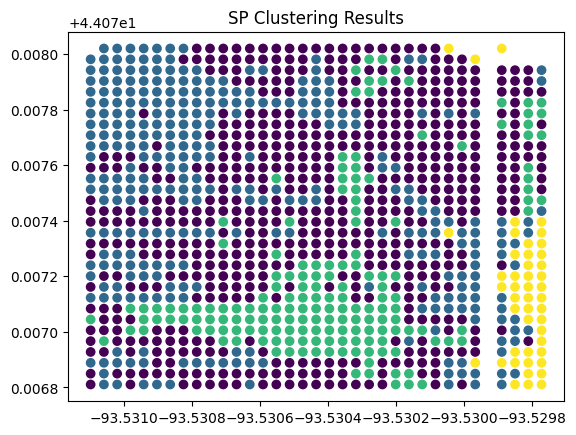

In [3]:
p1 = CombinedPreprocessor()

indices_6162021 = pd.read_csv("../Datasets/Indices_Combined/2021/June_16_2021.csv")
indices_6222021 = pd.read_csv("../Datasets/Indices_Combined/2021/June_22_2021.csv")
indices_6302021 = pd.read_csv("../Datasets/Indices_Combined/2021/June_30_2021.csv")
indices_7122021 = pd.read_csv("../Datasets/Indices_Combined/2021/July_12_2021.csv")
X_train_validate1, X_test1, Y_train_validate1, Y_test1 = p1.transform([indices_6162021, indices_6222021, indices_6302021], indices_7122021)

random_validator1 = RandomCV(models={'LR': LinearRegression(n_jobs=-1), 'RF': RandomForestRegressor(n_jobs=-1, random_state=41), 'XGB': XGBRegressor()})
gkf_validator1 = GroupKFoldCV(models={'LR': LinearRegression(n_jobs=-1), 'RF': RandomForestRegressor(n_jobs=-1, random_state=41), 'XGB': XGBRegressor()})
sp_validator1 = SpatialPlusCV(models={'LR': LinearRegression(n_jobs=-1), 'RF': RandomForestRegressor(n_jobs=-1, random_state=41), 'XGB': XGBRegressor()})
random_results1 = random_validator1.results(X_train_validate1, X_test1, Y_train_validate1, Y_test1)
gkf_results1 = gkf_validator1.results(X_train_validate1, X_test1, Y_train_validate1, Y_test1)
sp_results1 = sp_validator1.results(X_train_validate1, X_test1, Y_train_validate1, Y_test1)

display(random_results1, gkf_results1, sp_results1)
sp_validator1.display_clusters()

,Random,TYPE,RMSE_AVG,R2_AVG,RMSE STD,R2 STD
0,LR,CV,0.132576,0.272773,0.017861,0.185096
1,LR,TEST,0.389108,-5.859861,0.070541,2.377965
2,RF,CV,0.103424,0.568556,0.015363,0.052286
3,RF,TEST,0.137350,0.171430,0.004836,0.059031
4,XGB,CV,0.107159,0.532520,0.013714,0.071391
5,XGB,TEST,0.137972,0.158900,0.011743,0.142758


,GroupKFold,TYPE,RMSE_AVG,R2_AVG,RMSE STD,R2 STD
0,LR,CV,0.182202,-1.052549,0.091294,2.050600
1,LR,TEST,0.409989,-6.421527,0.033073,1.210791
2,RF,CV,0.127484,0.177979,0.031468,0.259126
3,RF,TEST,0.140867,0.125443,0.009664,0.122949
4,XGB,CV,0.134269,0.091801,0.035323,0.288949
5,XGB,TEST,0.139946,0.137803,0.008377,0.102203


,Spatial+,TYPE,RMSE_AVG,R2_AVG,RMSE STD,R2 STD
0,LR,CV,0.161056,-0.394341,0.059961,0.715132
1,LR,TEST,0.364163,-5.377981,0.113054,3.503950
2,RF,CV,0.125104,0.042890,0.018890,0.559895
3,RF,TEST,0.144033,0.088583,0.005633,0.070033
4,XGB,CV,0.132590,0.035690,0.020869,0.268246
5,XGB,TEST,0.146531,0.043598,0.018201,0.250150


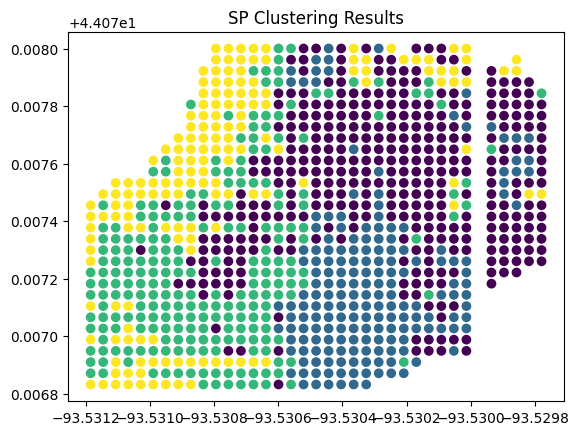

In [4]:
p2 = CombinedPreprocessor()

indices_6152022 = pd.read_csv("../Datasets/Indices_Combined/2022/June_15_2022.csv")
indices_6232022 = pd.read_csv("../Datasets/Indices_Combined/2022/June_23_2022.csv")
indices_6282022 = pd.read_csv("../Datasets/Indices_Combined/2022/June_28_2022.csv")
indices_7132022 = pd.read_csv("../Datasets/Indices_Combined/2022/July_13_2022.csv")
X_train_validate2, X_test2, Y_train_validate2, Y_test2 = p2.transform([indices_6152022, indices_6232022, indices_6282022], indices_7132022)

random_validator2 = RandomCV(models={'LR': LinearRegression(n_jobs=-1), 'RF': RandomForestRegressor(n_jobs=-1, random_state=41), 'XGB': XGBRegressor()})
gkf_validator2 = GroupKFoldCV(models={'LR': LinearRegression(n_jobs=-1), 'RF': RandomForestRegressor(n_jobs=-1, random_state=41), 'XGB': XGBRegressor()})
sp_validator2 = SpatialPlusCV(models={'LR': LinearRegression(n_jobs=-1), 'RF': RandomForestRegressor(n_jobs=-1, random_state=41), 'XGB': XGBRegressor()})
random_results2 = random_validator2.results(X_train_validate2, X_test2, Y_train_validate2, Y_test2)
gkf_results2 = gkf_validator2.results(X_train_validate2, X_test2, Y_train_validate2, Y_test2)
sp_results2 = sp_validator2.results(X_train_validate2, X_test2, Y_train_validate2, Y_test2)

display(random_results2, gkf_results2, sp_results2)
sp_validator2.display_clusters()

,Random,TYPE,RMSE_AVG,R2_AVG,RMSE STD,R2 STD
0,LR,CV,0.144977,0.539791,0.003391,0.020246
1,LR,TEST,0.556835,-6.590064,0.040566,1.085871
2,RF,CV,0.089465,0.824632,0.002430,0.010718
3,RF,TEST,0.459996,-4.237435,0.059129,1.254639
4,XGB,CV,0.095147,0.801422,0.004236,0.017975
5,XGB,TEST,0.413966,-3.198170,0.032314,0.675045


,GroupKFold,TYPE,RMSE_AVG,R2_AVG,RMSE STD,R2 STD
0,LR,CV,0.188382,0.110420,0.063029,0.485202
1,LR,TEST,0.554243,-6.936162,0.136892,3.791084
2,RF,CV,0.134314,0.561976,0.030476,0.144375
3,RF,TEST,0.404680,-3.332238,0.118962,2.101382
4,XGB,CV,0.152184,0.433280,0.041887,0.246987
5,XGB,TEST,0.368385,-2.604312,0.110975,1.942112


,Spatial+,TYPE,RMSE_AVG,R2_AVG,RMSE STD,R2 STD
0,LR,CV,0.191797,-0.527895,0.035903,1.074548
1,LR,TEST,0.520651,-5.767197,0.082704,2.098105
2,RF,CV,0.154882,0.069045,0.039287,0.497842
3,RF,TEST,0.370421,-2.574691,0.097952,1.942966
4,XGB,CV,0.170353,-0.103721,0.040877,0.497825
5,XGB,TEST,0.347433,-2.124353,0.087190,1.665367


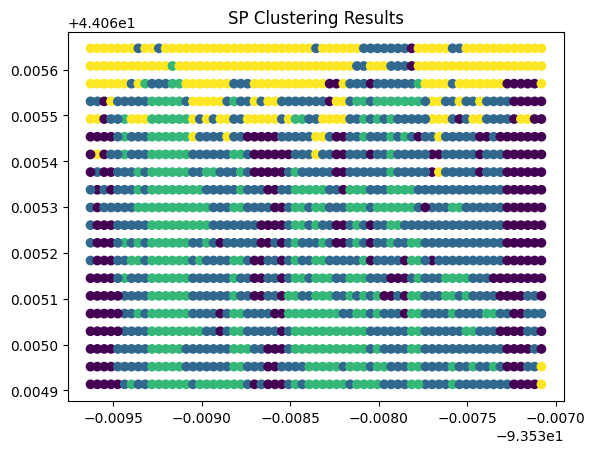

In [5]:
p = CombinedPreprocessor()

indices_6182020 = pd.read_csv("../Datasets/Indices_Combined/2020/June_18_2020_New.csv")
indices_6232020 = pd.read_csv("../Datasets/Indices_Combined/2020/June_23_2020_New.csv")
indices_6302020 = pd.read_csv("../Datasets/Indices_Combined/2020/June_30_2020_New.csv")
indices_7062020 = pd.read_csv("../Datasets/Indices_Combined/2021/June_30_2021.csv")

X_train_validate, X_test, Y_train_validate, Y_test = p.transform([indices_6182020, indices_6232020, indices_6302020], indices_7062020)

random_validator = RandomCV(models={'LR': LinearRegression(n_jobs=-1), 'RF': RandomForestRegressor(n_jobs=-1, random_state=41), 'XGB': XGBRegressor()})
gkf_validator = GroupKFoldCV(models={'LR': LinearRegression(n_jobs=-1), 'RF': RandomForestRegressor(n_jobs=-1, random_state=41), 'XGB': XGBRegressor()})
sp_validator = SpatialPlusCV(models={'LR': LinearRegression(n_jobs=-1), 'RF': RandomForestRegressor(random_state=41, n_jobs=-1), 'XGB': XGBRegressor()})
random_results = random_validator.results(X_train_validate, X_test, Y_train_validate, Y_test)
gkf_results = gkf_validator.results(X_train_validate, X_test, Y_train_validate, Y_test)
sp_results = sp_validator.results(X_train_validate, X_test, Y_train_validate, Y_test)

display(random_results, gkf_results, sp_results)
sp_validator.display_clusters()